In [1]:
import subprocess
result = subprocess.run(
    ["pip", "show", "speechbrain"], 
    capture_output=True, text=True
)
print(result.stdout)

Name: speechbrain
Version: 1.1.0
Summary: All-in-one speech toolkit in pure Python and Pytorch
Home-page: https://speechbrain.github.io/
Author: Mirco Ravanelli, Titouan Parcollet, Adel Moumen, Sylvain de Langen, Cem Subakan, Peter Plantinga, Yingzhi Wang, Pooneh Mousavi, Luca Della Libera, Artem Ploujnikov, Francesco Paissan, Davide Borra, Salah Zaiem, Zeyu Zhao, Shucong Zhang, Georgios Karakasidis, Sung-Lin Yeh, Pierre Champion, Aku Rouhe, Rudolf Braun, Florian Mai, Juan Zuluaga-Gomez, Seyed Mahed Mousavi, Andreas Nautsch, Ha Nguyen, Xuechen Liu, Sangeet Sagar, Jarod Duret, Salima Mdhaffar, Gaelle Laperriere, Mickael Rouvier, Renato De Mori, Yannick Esteve
Author-email: 
License: Apache-2.0
Location: D:\Bachelor Project Code\.venv\Lib\site-packages
Requires: huggingface_hub, hyperpyyaml, joblib, numpy, packaging, requests, scipy, sentencepiece, soundfile, torch, torchaudio, tqdm
Required-by: 



In [2]:
# ============================================================
# SPEECHBRAIN MODEL — via HuggingFace transformers (bez k2)
# Model: wav2vec2 trenowany na IEMOCAP (4 emocje)
# ============================================================

from transformers import pipeline
import torch

print("Loading model...")
classifier = pipeline(
    "audio-classification",
    model="superb/wav2vec2-base-superb-er",
    device="cpu"
)
print("Model loaded.")

TEST_FILE = r"D:\Bachelor Project Code\Audio_Speech_Actors_01-24\Actor_01\03-01-01-01-01-01-01.wav"

result = classifier(TEST_FILE, top_k=4)
print(f"\nFile: neutral speech (Actor 01)")
print(f"Results:")
for r in result:
    bar = "█" * int(r["score"] * 30)
    print(f"  {r['label']:8s} {r['score']:.3f}  {bar}")

d:\Bachelor Project Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model...


d:\Bachelor Project Code\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\macie\.cache\huggingface\hub\models--superb--wav2vec2-base-superb-er. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 216/216 [00:00<00:00, 15695.94it/s]


Model loaded.

File: neutral speech (Actor 01)
Results:
  neu      0.585  █████████████████
  hap      0.373  ███████████
  ang      0.029  
  sad      0.013  


In [3]:
# ============================================================
# SPEECHBRAIN (wav2vec2) — BATCH: RAVDESS + ElevenLabs
# 4 klasy: neu, hap, sad, ang
# Zapisuje wyniki na bieżąco do CSV
# ============================================================

from transformers import pipeline
import pandas as pd
from pathlib import Path
import re, time

# ── PATHS & MODEL ────────────────────────────────────────────
RAVDESS_DIR    = Path(r"D:\Bachelor Project Code\Audio_Speech_Actors_01-24")
ELEVENLABS_DIR = Path(r"D:\Bachelor Project Code\ElevenLabs_Speech_Voices")
OUT_RAVDESS    = Path(r"D:\Bachelor Project Code\Code\sb_ravdess_results.csv")
OUT_ELEVENLABS = Path(r"D:\Bachelor Project Code\Code\sb_elevenlabs_results.csv")

# Model już załadowany — użyj ponownie
print("Loading model...")
classifier = pipeline(
    "audio-classification",
    model="superb/wav2vec2-base-superb-er",
    device="cpu"
)
print("Model loaded.\n")

# ── MAPPING ──────────────────────────────────────────────────
# SpeechBrain ma 4 klasy — mapujemy tylko te 4
SB_LABEL_MAP = {
    "neu": "neutral",
    "hap": "happy",
    "sad": "sad",
    "ang": "angry"
}
# Emocje które możemy ocenić (fearful i disgust pomijamy w accuracy)
SB_EMOTIONS = {"neutral", "happy", "sad", "angry"}

RAVDESS_EMOTION_MAP = {
    "01": "neutral", "02": "calm",    "03": "happy",
    "04": "sad",     "05": "angry",   "06": "fearful",
    "07": "disgust", "08": "surprised"
}

TARGET_EMOTIONS = {"neutral", "happy", "sad", "angry", "fearful", "disgust"}

# ── COLLECT FILES ─────────────────────────────────────────────
def collect_ravdess(ravdess_dir):
    files = []
    for wav in sorted(ravdess_dir.rglob("*.wav")):
        parts = wav.stem.split("-")
        if len(parts) != 7:
            continue
        modality, channel, emo, intensity, statement, rep, actor = parts
        if modality != "03" or channel != "01":
            continue
        emotion = RAVDESS_EMOTION_MAP.get(emo)
        if emotion not in TARGET_EMOTIONS:
            continue
        files.append({
            "path":      str(wav),
            "source":    "human",
            "voice":     f"Actor_{actor}",
            "emotion":   emotion,
            "intensity": "normal" if intensity == "01" else "strong",
            "statement": "kids" if statement == "01" else "dogs",
            "rep":       rep,
            "actor":     actor,
            "gender":    "M" if int(actor) % 2 == 1 else "F"
        })
    return files

def collect_elevenlabs(elevenlabs_dir):
    files = []
    pattern = re.compile(
        r"ELv3_(\w+)_([CNS])_(\w+)_(kids|dogs)_(g[12])\.wav",
        re.IGNORECASE
    )
    for wav in sorted(elevenlabs_dir.rglob("*.wav")):
        m = pattern.match(wav.name)
        if not m:
            continue
        voice, mode, emotion, statement, gen = m.groups()
        emotion = emotion.lower()
        if emotion not in TARGET_EMOTIONS:
            continue
        files.append({
            "path":      str(wav),
            "source":    "ai",
            "voice":     voice,
            "emotion":   emotion,
            "intensity": "normal",
            "statement": statement,
            "rep":       gen,
            "mode":      {"C":"creative","N":"natural","S":"solid"}[mode.upper()]
        })
    return files

# ── BATCH FUNCTION ────────────────────────────────────────────
def run_batch(files, output_csv, label):
    # Resume
    if output_csv.exists():
        df_existing = pd.read_csv(output_csv)
        done_paths  = set(df_existing["path"].tolist())
        results     = df_existing.to_dict("records")
        print(f"Resume: {len(done_paths)} already done")
    else:
        done_paths = set()
        results    = []

    todo = [f for f in files if f["path"] not in done_paths]
    total = len(files)
    print(f"{label}: {len(todo)} files to process\n")

    for i, file_info in enumerate(todo):
        path  = file_info["path"]
        fname = Path(path).name
        true_emotion = file_info["emotion"]

        try:
            preds = classifier(path, top_k=4)

            # Top prediction
            top       = preds[0]
            predicted = SB_LABEL_MAP.get(top["label"], top["label"])

            # Scores for all 4 classes
            score_dict = {SB_LABEL_MAP.get(p["label"], p["label"]): p["score"]
                          for p in preds}

            # Correct only if true emotion is in SB's 4 classes
            if true_emotion in SB_EMOTIONS:
                correct = predicted == true_emotion
            else:
                correct = None  # fearful/disgust — nie oceniamy

            row = {
                **file_info,
                "sb_predicted":  predicted,
                "correct":       correct,
                "score_neutral": score_dict.get("neutral", 0),
                "score_happy":   score_dict.get("happy", 0),
                "score_sad":     score_dict.get("sad", 0),
                "score_angry":   score_dict.get("angry", 0),
            }
            results.append(row)
            pd.DataFrame(results).to_csv(output_csv, index=False)

            done_count = len(done_paths) + i + 1
            icon = "✓" if correct else ("~" if correct is None else "✗")
            print(f"[{done_count:4d}/{total}] {icon} {fname}")
            print(f"           true={true_emotion:8s} pred={predicted}")

        except Exception as e:
            print(f"[{i+1:4d}/{total}] ERROR: {fname} — {e}")

    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)

    # Summary — tylko emocje które SB zna
    df_eval = df[df["correct"].notna()].copy()
    df_eval["correct"] = df_eval["correct"].astype(bool)

    print(f"\n{'='*50}")
    print(f"DONE: {label}")
    print(f"Evaluated: {len(df_eval)} files (4 emotions only)")
    print(f"Overall accuracy: {df_eval['correct'].mean():.1%}")
    print(f"\nAccuracy by emotion:")
    print(df_eval.groupby("emotion")["correct"].mean()
                 .sort_values(ascending=False)
                 .apply(lambda x: f"{x:.1%}").to_string())
    return df

# ── RUN ───────────────────────────────────────────────────────
ravdess_files    = collect_ravdess(RAVDESS_DIR)
elevenlabs_files = collect_elevenlabs(ELEVENLABS_DIR)

print(f"RAVDESS files:    {len(ravdess_files)}")
print(f"ElevenLabs files: {len(elevenlabs_files)}")
print()

# Najpierw ElevenLabs (krócej), potem RAVDESS (przez noc)
df_ai    = run_batch(elevenlabs_files, OUT_ELEVENLABS, "ElevenLabs")
df_human = run_batch(ravdess_files,    OUT_RAVDESS,    "RAVDESS")

Loading model...


Loading weights: 100%|██████████| 216/216 [00:00<00:00, 26679.12it/s]


Model loaded.

RAVDESS files:    1056
ElevenLabs files: 240

ElevenLabs: 240 files to process

[   1/240] ✓ ELv3_adam01_C_angry_dogs_g1.wav
           true=angry    pred=angry
[   2/240] ✓ ELv3_adam01_C_angry_dogs_g2.wav
           true=angry    pred=angry
[   3/240] ✓ ELv3_adam01_C_angry_kids_g1.wav
           true=angry    pred=angry
[   4/240] ✓ ELv3_adam01_C_angry_kids_g2.wav
           true=angry    pred=angry
[   5/240] ~ ELv3_adam01_C_disgust_dogs_g1.wav
           true=disgust  pred=angry
[   6/240] ~ ELv3_adam01_C_disgust_dogs_g2.wav
           true=disgust  pred=neutral
[   7/240] ~ ELv3_adam01_C_disgust_kids_g1.wav
           true=disgust  pred=angry
[   8/240] ~ ELv3_adam01_C_disgust_kids_g2.wav
           true=disgust  pred=angry
[   9/240] ~ ELv3_adam01_C_fearful_dogs_g1.wav
           true=fearful  pred=angry
[  10/240] ~ ELv3_adam01_C_fearful_dogs_g2.wav
           true=fearful  pred=angry
[  11/240] ~ ELv3_adam01_C_fearful_kids_g1.wav
           true=fearful  pred=sad


SPEECHBRAIN — HUMAN vs AI VOICE ACCURACY (H2 TEST)

Overall accuracy (4 emotions only):
  Human voice (RAVDESS):   42.9%
  AI voice (ElevenLabs):   35.6%
  Difference:              -7.2%

Accuracy by emotion:
Emotion        Human        AI      Diff
------------------------------------------
neutral        60.4%     65.0%     +4.6%
happy          17.2%      0.0%    -17.2%
sad             7.3%      2.5%     -4.8%
angry          95.3%     75.0%    -20.3%

Human accuracy by intensity:
intensity
normal    45.3%
strong    39.6%

Human accuracy by gender:
gender
F    41.1%
M    44.6%

AI accuracy by mode:
mode
creative    40.6%
natural     35.4%
solid       31.2%

AI accuracy by voice:
voice
ryan01      43.8%
ivy01       43.8%
adam01      39.6%
sarah01     37.5%
lucius01    31.2%
hope01      27.1%


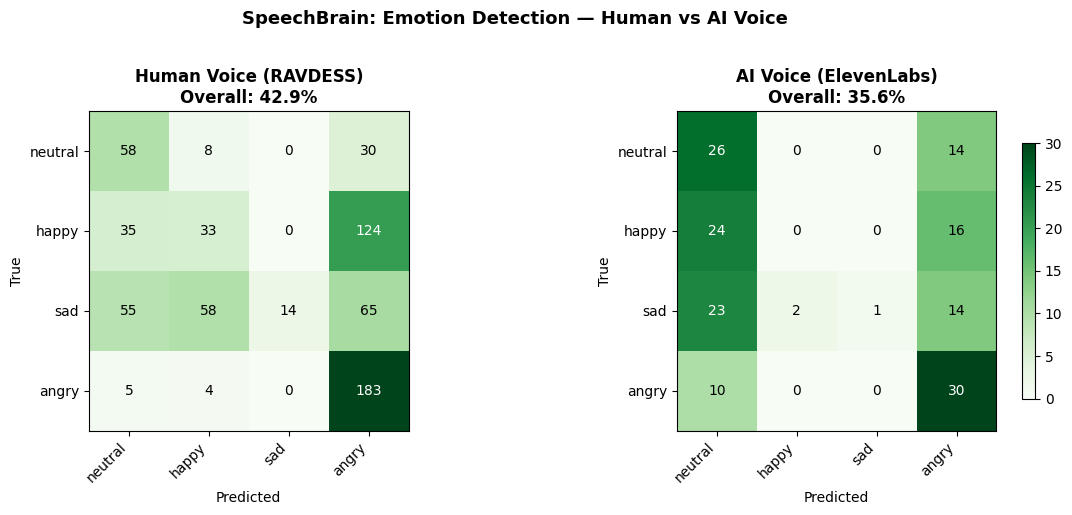

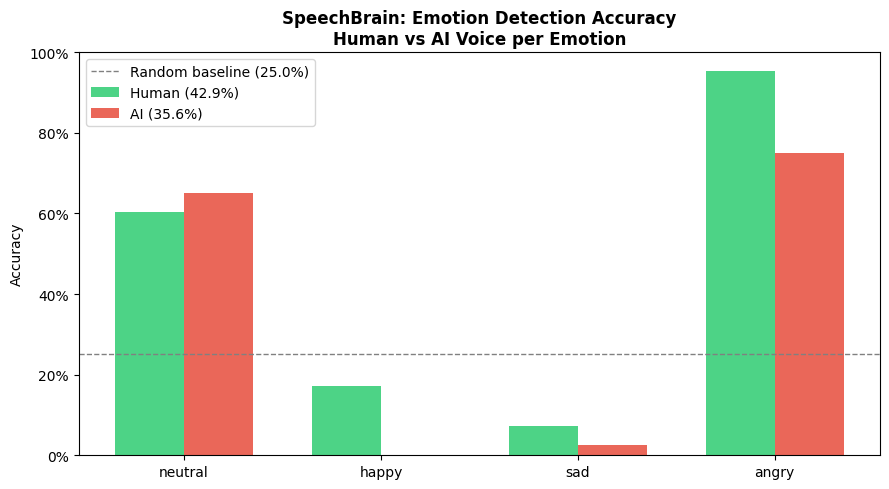

Plots saved.


In [4]:
# ============================================================
# SPEECHBRAIN — HUMAN vs AI COMPARISON
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

df_human = pd.read_csv(r"D:\Bachelor Project Code\Code\sb_ravdess_results.csv")
df_ai    = pd.read_csv(r"D:\Bachelor Project Code\Code\sb_elevenlabs_results.csv")

SB_EMOTIONS = ["neutral", "happy", "sad", "angry"]

# Filtruj tylko emocje które SB zna
dh = df_human[df_human["emotion"].isin(SB_EMOTIONS)].copy()
da = df_ai[df_ai["emotion"].isin(SB_EMOTIONS)].copy()
dh["correct"] = dh["correct"].astype(bool)
da["correct"] = da["correct"].astype(bool)

overall_h = dh["correct"].mean()
overall_a = da["correct"].mean()

print("=" * 55)
print("SPEECHBRAIN — HUMAN vs AI VOICE ACCURACY (H2 TEST)")
print("=" * 55)
print(f"\nOverall accuracy (4 emotions only):")
print(f"  Human voice (RAVDESS):   {overall_h:.1%}")
print(f"  AI voice (ElevenLabs):   {overall_a:.1%}")
print(f"  Difference:              {overall_a - overall_h:+.1%}")

print(f"\nAccuracy by emotion:")
print(f"{'Emotion':10s}  {'Human':>8s}  {'AI':>8s}  {'Diff':>8s}")
print("-" * 42)
for emo in SB_EMOTIONS:
    h = dh[dh["emotion"]==emo]["correct"].mean()
    a = da[da["emotion"]==emo]["correct"].mean()
    print(f"{emo:10s}  {h:>8.1%}  {a:>8.1%}  {a-h:>+8.1%}")

print(f"\nHuman accuracy by intensity:")
print(dh.groupby("intensity")["correct"].mean()
        .apply(lambda x: f"{x:.1%}").to_string())

print(f"\nHuman accuracy by gender:")
print(dh.groupby("gender")["correct"].mean()
        .apply(lambda x: f"{x:.1%}").to_string())

print(f"\nAI accuracy by mode:")
da_mode = df_ai[df_ai["emotion"].isin(SB_EMOTIONS) & df_ai["mode"].notna()]
print(da_mode.groupby("mode")["correct"].mean()
             .apply(lambda x: f"{x:.1%}").to_string())

print(f"\nAI accuracy by voice:")
print(da.groupby("voice")["correct"].mean()
        .sort_values(ascending=False)
        .apply(lambda x: f"{x:.1%}").to_string())

# ── CONFUSION MATRICES ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (df, title, overall) in zip(axes, [
    (dh, f"Human Voice (RAVDESS)\nOverall: {overall_h:.1%}", overall_h),
    (da, f"AI Voice (ElevenLabs)\nOverall: {overall_a:.1%}",  overall_a)
]):
    cm = pd.crosstab(
        df["emotion"], df["sb_predicted"],
        rownames=["True"], colnames=["Predicted"]
    ).reindex(index=SB_EMOTIONS, columns=SB_EMOTIONS, fill_value=0)

    im = ax.imshow(cm.values, cmap="Greens")
    ax.set_xticks(range(len(SB_EMOTIONS)))
    ax.set_yticks(range(len(SB_EMOTIONS)))
    ax.set_xticklabels(SB_EMOTIONS, rotation=45, ha="right")
    ax.set_yticklabels(SB_EMOTIONS)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title, fontsize=12, fontweight="bold")
    for i in range(len(SB_EMOTIONS)):
        for j in range(len(SB_EMOTIONS)):
            val = cm.values[i, j]
            color = "white" if val > cm.values.max()*0.6 else "black"
            ax.text(j, i, str(val), ha="center", va="center",
                    color=color, fontsize=10)

plt.colorbar(im, ax=axes[1], shrink=0.8)
plt.suptitle("SpeechBrain: Emotion Detection — Human vs AI Voice",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(r"D:\Bachelor Project Code\Code\sb_confusion_matrices.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── BAR CHART ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(SB_EMOTIONS))
width = 0.35

human_acc = [dh[dh["emotion"]==e]["correct"].mean() for e in SB_EMOTIONS]
ai_acc    = [da[da["emotion"]==e]["correct"].mean()  for e in SB_EMOTIONS]

ax.bar(x - width/2, human_acc, width,
       label=f"Human ({overall_h:.1%})", color="#2ecc71", alpha=0.85)
ax.bar(x + width/2, ai_acc, width,
       label=f"AI ({overall_a:.1%})",    color="#e74c3c", alpha=0.85)
ax.axhline(0.25, color="gray", linestyle="--", linewidth=1,
           label="Random baseline (25.0%)")
ax.set_xticks(x)
ax.set_xticklabels(SB_EMOTIONS)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_title("SpeechBrain: Emotion Detection Accuracy\nHuman vs AI Voice per Emotion",
             fontsize=12, fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig(r"D:\Bachelor Project Code\Code\sb_accuracy_per_emotion.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plots saved.")

COMPONENT 3 — FINAL SUMMARY: H2 ECHO CHAMBER HYPOTHESIS TEST

Detector         Human Voice   AI Voice     Diff
--------------------------------------------------
Hume AI (6 emo)        42.0%      29.2%   -12.8%
Hume AI (4 emo)        47.2%      33.8%   -13.5%
SpeechBrain            42.9%      35.6%    -7.2%

Emotion     Hume Human   Hume AI   SB Human    SB AI
-------------------------------------------------------
neutral          96.9%     57.5%      60.4%    65.0%
happy            40.3%     27.5%      17.2%     0.0%
sad              31.8%     17.5%       7.3%     2.5%
angry            44.8%     32.5%      95.3%    75.0%

H2 VERDICT:
  Hume AI:     AI > Human? False → H2 REJECTED
  SpeechBrain: AI > Human? False  → H2 REJECTED

  CONCLUSION: H2 rejected by both detectors.
  Human voice consistently better recognized than AI voice.
  Exception: SpeechBrain neutral (+4.6% for AI) — consistent with H1
  (AI voice defaults toward neutrality, making neutral easy to detect)


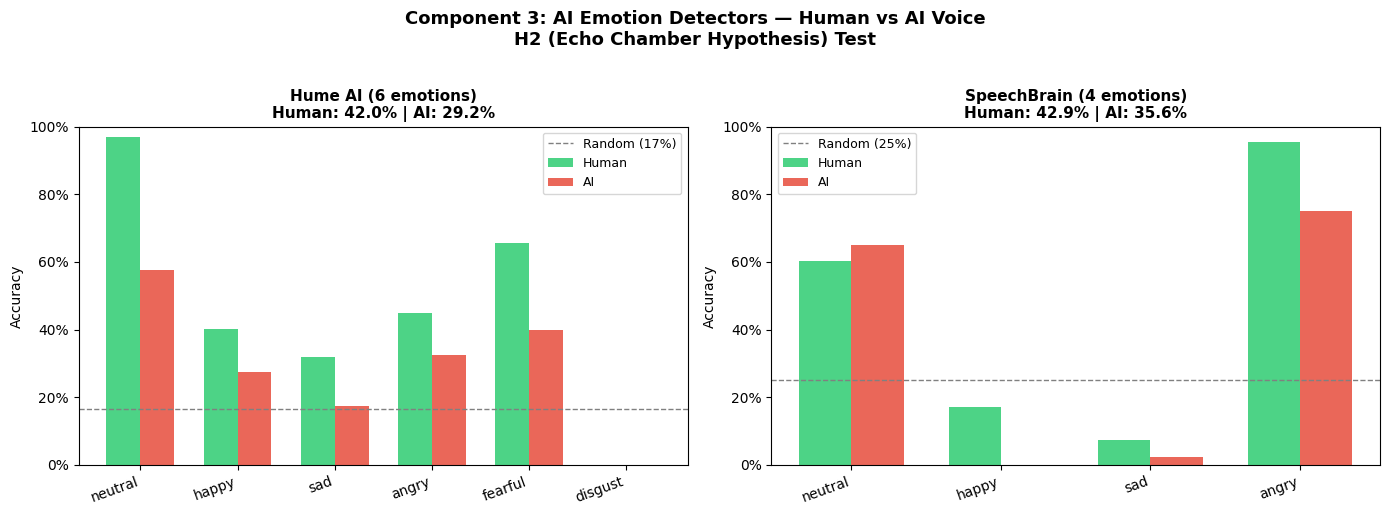

Saved: component3_final_summary.png


: 

In [ ]:
# ============================================================
# FINAL SUMMARY — Hume AI vs SpeechBrain vs Human
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Hume wyniki
hume_h = pd.read_csv(r"D:\Bachelor Project Code\Code\hume_ravdess_results.csv")
hume_a = pd.read_csv(r"D:\Bachelor Project Code\Code\hume_elevenlabs_results.csv")

# SpeechBrain wyniki
sb_h = pd.read_csv(r"D:\Bachelor Project Code\Code\sb_ravdess_results.csv")
sb_a = pd.read_csv(r"D:\Bachelor Project Code\Code\sb_elevenlabs_results.csv")

SB_EMOTIONS   = ["neutral", "happy", "sad", "angry"]
ALL_EMOTIONS  = ["neutral", "happy", "sad", "angry", "fearful", "disgust"]

# Filtruj SB do 4 emocji
sb_h_4 = sb_h[sb_h["emotion"].isin(SB_EMOTIONS)].copy()
sb_a_4 = sb_a[sb_a["emotion"].isin(SB_EMOTIONS)].copy()
sb_h_4["correct"] = sb_h_4["correct"].astype(bool)
sb_a_4["correct"] = sb_a_4["correct"].astype(bool)

# Filtruj Hume do tych samych 4 emocji (dla fair comparison)
hume_h_4 = hume_h[hume_h["emotion"].isin(SB_EMOTIONS)].copy()
hume_a_4 = hume_a[hume_a["emotion"].isin(SB_EMOTIONS)].copy()

print("=" * 65)
print("COMPONENT 3 — FINAL SUMMARY: H2 ECHO CHAMBER HYPOTHESIS TEST")
print("=" * 65)

print(f"\n{'Detector':15s} {'Human Voice':>12s} {'AI Voice':>10s} {'Diff':>8s}")
print("-" * 50)
print(f"{'Hume AI (6 emo)':15s} {hume_h['correct'].mean():>12.1%} "
      f"{hume_a['correct'].mean():>10.1%} "
      f"{hume_a['correct'].mean()-hume_h['correct'].mean():>+8.1%}")
print(f"{'Hume AI (4 emo)':15s} {hume_h_4['correct'].mean():>12.1%} "
      f"{hume_a_4['correct'].mean():>10.1%} "
      f"{hume_a_4['correct'].mean()-hume_h_4['correct'].mean():>+8.1%}")
print(f"{'SpeechBrain':15s} {sb_h_4['correct'].mean():>12.1%} "
      f"{sb_a_4['correct'].mean():>10.1%} "
      f"{sb_a_4['correct'].mean()-sb_h_4['correct'].mean():>+8.1%}")

print(f"\n{'Emotion':10s}  {'Hume Human':>10s}  {'Hume AI':>8s}  "
      f"{'SB Human':>9s}  {'SB AI':>7s}")
print("-" * 55)
for emo in SB_EMOTIONS:
    hh = hume_h_4[hume_h_4["emotion"]==emo]["correct"].mean()
    ha = hume_a_4[hume_a_4["emotion"]==emo]["correct"].mean()
    sh = sb_h_4[sb_h_4["emotion"]==emo]["correct"].mean()
    sa = sb_a_4[sb_a_4["emotion"]==emo]["correct"].mean()
    print(f"{emo:10s}  {hh:>10.1%}  {ha:>8.1%}  {sh:>9.1%}  {sa:>7.1%}")

print(f"\nH2 VERDICT:")
hume_supports = hume_a["correct"].mean() > hume_h["correct"].mean()
sb_supports   = sb_a_4["correct"].mean() > sb_h_4["correct"].mean()
print(f"  Hume AI:     AI > Human? {hume_supports} → H2 {'SUPPORTED' if hume_supports else 'REJECTED'}")
print(f"  SpeechBrain: AI > Human? {sb_supports}  → H2 {'SUPPORTED' if sb_supports else 'REJECTED'}")
print(f"\n  CONCLUSION: H2 rejected by both detectors.")
print(f"  Human voice consistently better recognized than AI voice.")
print(f"  Exception: SpeechBrain neutral (+4.6% for AI) — consistent with H1")
print(f"  (AI voice defaults toward neutrality, making neutral easy to detect)")

# ── COMBINED CHART ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (detector, h_acc, a_acc, emotions, baseline, title) in zip(axes, [
    ("Hume AI",
     [hume_h[hume_h["emotion"]==e]["correct"].mean() for e in ALL_EMOTIONS],
     [hume_a[hume_a["emotion"]==e]["correct"].mean() for e in ALL_EMOTIONS],
     ALL_EMOTIONS, 1/6,
     f"Hume AI (6 emotions)\nHuman: {hume_h['correct'].mean():.1%} | AI: {hume_a['correct'].mean():.1%}"),
    ("SpeechBrain",
     [sb_h_4[sb_h_4["emotion"]==e]["correct"].mean() for e in SB_EMOTIONS],
     [sb_a_4[sb_a_4["emotion"]==e]["correct"].mean() for e in SB_EMOTIONS],
     SB_EMOTIONS, 0.25,
     f"SpeechBrain (4 emotions)\nHuman: {sb_h_4['correct'].mean():.1%} | AI: {sb_a_4['correct'].mean():.1%}")
]):
    x = np.arange(len(emotions))
    w = 0.35
    ax.bar(x - w/2, h_acc, w, label="Human", color="#2ecc71", alpha=0.85)
    ax.bar(x + w/2, a_acc, w, label="AI",    color="#e74c3c", alpha=0.85)
    ax.axhline(baseline, color="gray", linestyle="--",
               linewidth=1, label=f"Random ({baseline:.0%})")
    ax.set_xticks(x)
    ax.set_xticklabels(emotions, rotation=20, ha="right")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.suptitle("Component 3: AI Emotion Detectors — Human vs AI Voice\n"
             "H2 (Echo Chamber Hypothesis) Test",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(r"D:\Bachelor Project Code\Code\component3_final_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: component3_final_summary.png")